In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded=files.upload()

Saving loan.csv to loan.csv


In [5]:
df=pd.read_csv("loan.csv")

In [6]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [8]:
df = df[['loan_amnt',
         'term',
         'int_rate',
         'annual_inc',
         'emp_length',
         'home_ownership',
         'purpose',
         'grade',
         'loan_status']]

In [9]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
annual_inc,0
emp_length,18301
home_ownership,0
purpose,0
grade,0
loan_status,0


In [11]:
df.dropna(inplace=True)

In [12]:
df['term'] = df['term'].str.replace(' months', '')
df['term'] = df['term'].astype(int)

In [18]:
df = pd.get_dummies(df,
                    columns=['home_ownership', 'purpose', 'grade'],
                    drop_first=True)

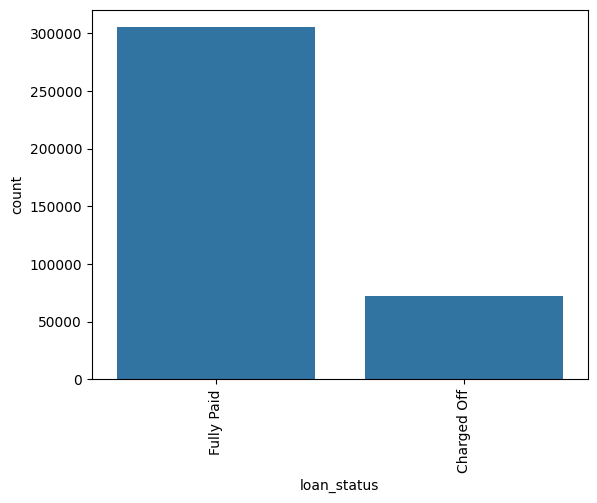

In [19]:
sns.countplot(x='loan_status', data=df)
plt.xticks(rotation=90)
plt.show()

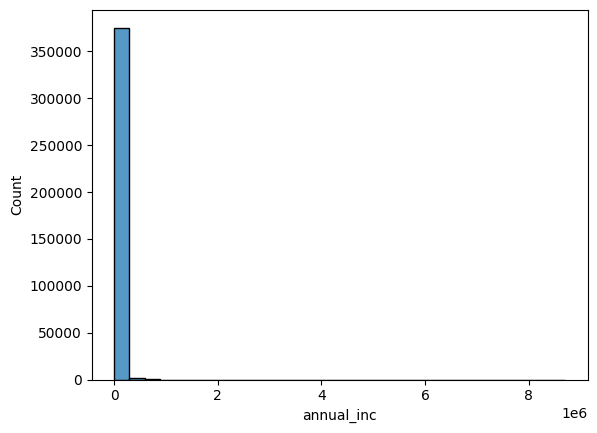

In [20]:
sns.histplot(df['annual_inc'], bins=30)
plt.show()

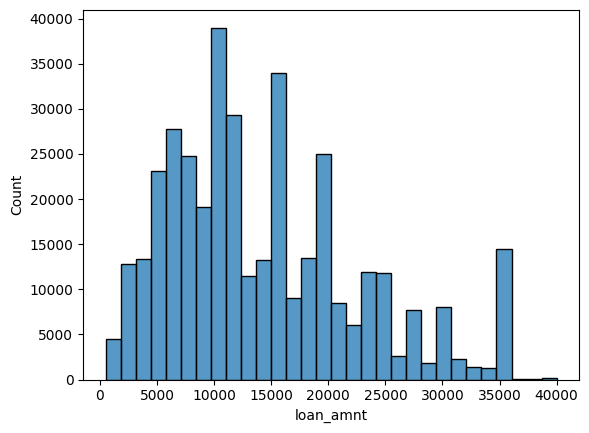

In [21]:
sns.histplot(df['loan_amnt'], bins=30)
plt.show()

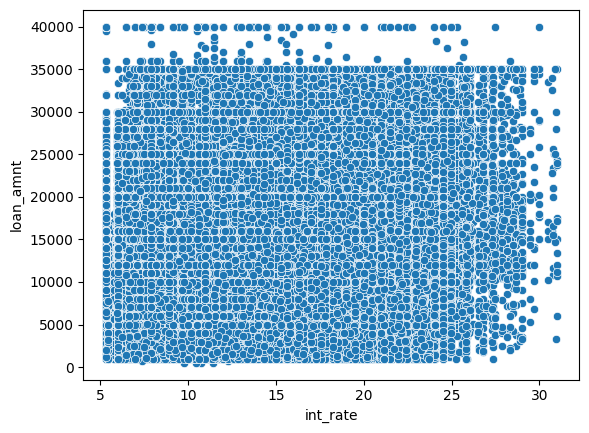

In [22]:
sns.scatterplot(x='int_rate', y='loan_amnt', data=df)
plt.show()

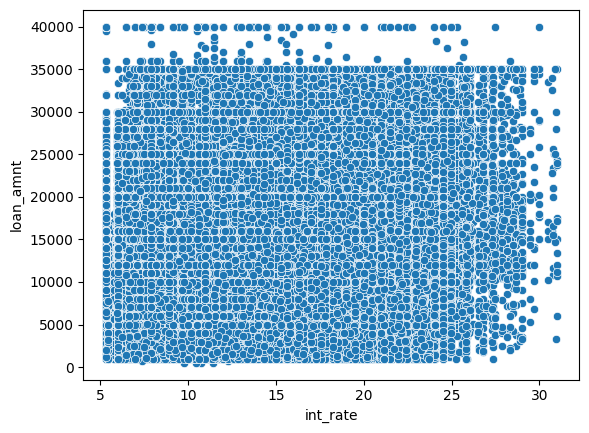

In [23]:
sns.scatterplot(x='int_rate', y='loan_amnt', data=df)
plt.show()

In [25]:
def risk_category(rate):
    if rate < 10:
        return "Low Risk"
    elif rate < 20:
        return "Medium Risk"
    else:
        return "High Risk"

df['risk_level'] = df['int_rate'].apply(risk_category)

In [26]:
df['risk_level'].value_counts()

,count
risk_level,
Medium Risk,259161
Low Risk,87546
High Risk,31022


In [27]:
X = df[['annual_inc', 'int_rate', 'term']]
y = df['loan_amnt']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [30]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print(score)

0.2581070913228215


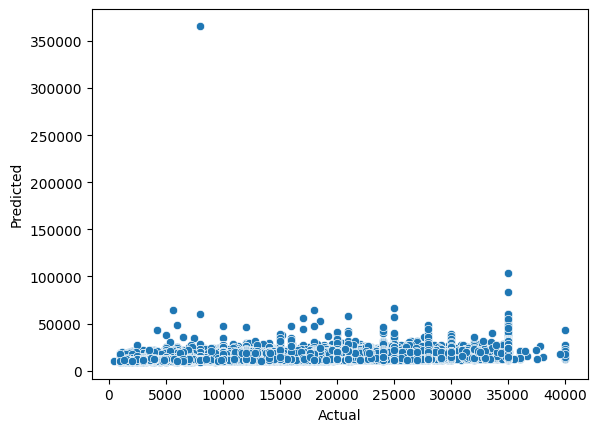

In [32]:
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [33]:
import plotly.express as px

fig = px.scatter(df,
                 x='annual_inc',
                 y='loan_amnt',
                 color='loan_status')

fig.show()